## **RecycleVision- Garbage Image Classification**

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import tensorflow as tf
import os

data_dir = "/content/drive/MyDrive/RecycleVision- Garbage Image Classification/Data"

img_size = (224, 224)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 2537 files belonging to 6 classes.
Using 2030 files for training.
Found 2537 files belonging to 6 classes.
Using 507 files for validation.
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [10]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)

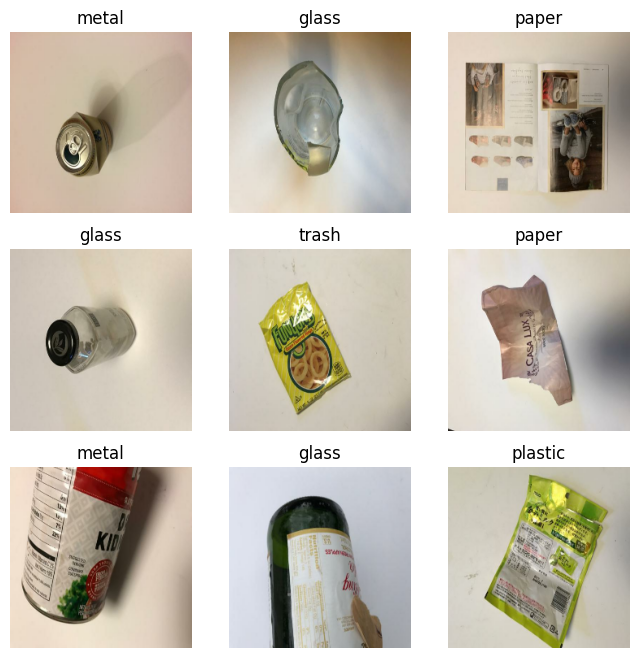

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [12]:
from tensorflow import keras
from tensorflow.keras import layers

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ]
)

normalization_layer = layers.Rescaling(1./255)

In [13]:
IMG_SIZE = (224, 224)
NUM_CLASSES = len(class_names)

base_model = keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False  # pehle sirf top layers train karenge

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [14]:
inputs = keras.Input(shape=IMG_SIZE + (3,))

x = data_augmentation(inputs)
x = normalization_layer(x)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [17]:
epochs = 20

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.8720 - loss: 0.3468 - val_accuracy: 0.8225 - val_loss: 0.4979
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - accuracy: 0.8764 - loss: 0.3270 - val_accuracy: 0.8383 - val_loss: 0.4893
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.8848 - loss: 0.3137 - val_accuracy: 0.8343 - val_loss: 0.4830
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 131s 2s/step - accuracy: 0.8881 - loss: 0.3193 - val_accuracy: 0.8146 - val_loss: 0.4889
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 149s 2s/step - accuracy: 0.8685 - loss: 0.3515 - val_accuracy: 0.8166 - val_loss: 0.5156
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 150s 2s/step - accuracy: 0.8763 - loss: 0.3308 - val_accuracy: 0.8166 - val_loss: 0.4993
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 148s 2s/step - accuracy: 0.8627 - loss: 0.3363 - val_accuracy: 0.8245 - val_loss: 0.5142
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 150s 2s/step - accuracy: 0.8733 - loss: 0.3475 - val_accuracy: 0.8323 - v

In [18]:
from tensorflow import keras

base_model.trainable = True  # ab poora unfreeze

# sirf last ~40 layers train karni hain, neeche wali frozen rahengi
fine_tune_at = 100  # MobileNetV2 me ~155 layers hoti hain

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()



Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 1,869,126 (7.13 MB)

 Non-trainable params: 396,544 (1.51 MB)

In [19]:
fine_tune_epochs = 10
total_epochs = 20 + fine_tune_epochs   # agar pehle 20 epochs kiye the

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=total_epochs,
    initial_epoch=20   # pehle jitne epochs chalaye the utna
)


Epoch 21/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 229s 3s/step - accuracy: 0.7053 - loss: 0.9479 - val_accuracy: 0.7653 - val_loss: 0.9067
Epoch 22/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 206s 3s/step - accuracy: 0.8447 - loss: 0.4172 - val_accuracy: 0.8107 - val_loss: 0.7916
Epoch 23/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 189s 3s/step - accuracy: 0.8914 - loss: 0.2968 - val_accuracy: 0.7949 - val_loss: 0.9682
Epoch 24/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 221s 3s/step - accuracy: 0.9021 - loss: 0.2618 - val_accuracy: 0.7140 - val_loss: 1.4589
Epoch 25/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 204s 3s/step - accuracy: 0.9318 - loss: 0.1847 - val_accuracy: 0.7692 - val_loss: 0.9999
Epoch 26/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 205s 3s/step - accuracy: 0.9474 - loss: 0.1539 - val_accuracy: 0.7574 - val_loss: 0.9899
Epoch 27/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 212s 3s/step - accuracy: 0.9372 - loss: 0.1631 - val_accuracy: 0.8146 - val_loss: 0.7263
Epoch 28/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 205s 3s/step - accuracy: 0.9564 - loss: 0.1401 - val_accuracy: 0.

In [20]:
import tensorflow as tf

data_dir = "/content/drive/MyDrive/RecycleVision- Garbage Image Classification/Data"
img_size = (224, 224)
batch_size = 32

test_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    shuffle=False,          # IMPORTANT
    image_size=img_size,
    batch_size=batch_size
)

class_names = test_ds.class_names


Found 2537 files belonging to 6 classes.


In [21]:
import numpy as np

y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0)

y_prob = model.predict(test_ds)
y_pred = np.argmax(y_prob, axis=1)

80/80 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step


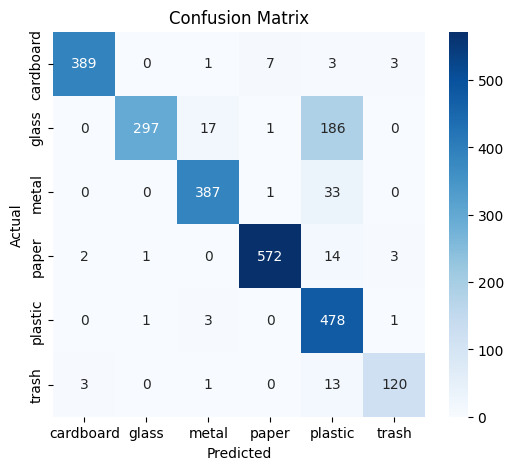

              precision    recall  f1-score   support

   cardboard       0.99      0.97      0.98       403
       glass       0.99      0.59      0.74       501
       metal       0.95      0.92      0.93       421
       paper       0.98      0.97      0.98       592
     plastic       0.66      0.99      0.79       483
       trash       0.94      0.88      0.91       137

    accuracy                           0.88      2537
   macro avg       0.92      0.88      0.89      2537
weighted avg       0.92      0.88      0.88      2537



In [22]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

In [23]:
import os

save_dir = "/content/drive/MyDrive/RecycleVision- Garbage Image Classification/models"
os.makedirs(save_dir, exist_ok=True)

model_path = os.path.join(save_dir, "recyclevision_mobilenetv2.h5")
model.save(model_path)

print("Saved to:", model_path)

Saved to: /content/drive/MyDrive/RecycleVision- Garbage Image Classification/models/recyclevision_mobilenetv2.h5
